# Earnings-Season-Tide 🌊
### Does the whole market drift differently during peak earnings weeks?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Separable tide%3F: Not supported](https://img.shields.io/badge/Separable_tide%3F-Not_supported-8b949e?style=flat-square)

Four times a year, for a couple of weeks, almost every big company reports its earnings at once — mid-late January, April, July and October. It *feels* like the market should move to a different rhythm in those windows. This notebook asks, in plain language, whether the whole index really has an 'earnings-season tide' you could lean on — and answers: it drifts a hair faster, but the gap is lost in the noise, and trying to ride it under-performs just holding the index.

> 📓 **This is the plain-language layer.** Want the HAC *t*-stats, the bootstrap CI and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from earnings_season_tide import data, strategy as st

# Frozen real-tape headline numbers (mirror of ../docs/results.md, as-of 2026-06-18).
R = {'as_of': '2026-06-18', 'fingerprint': 'ff2579c16a7d', 'span': '1993-01-29 → 2025-12-31', 'n_days': 8288, 'n_in': 1737, 'n_out': 6550, 'mean_in_bps': 6.86, 'mean_out_bps': 3.28, 'diff_bps': 3.59, 'ann_in_pct': 17.3, 'ann_out_pct': 8.3, 'tstat_diff': 1.27, 'ci_lo': -1.67, 'ci_hi': 9.17, 'jan_bps': 0.37, 'jan_t': -0.72, 'apr_bps': 9.15, 'apr_t': 1.23, 'jul_bps': 5.44, 'jul_t': 0.33, 'oct_bps': 11.16, 'oct_t': 1.39, 'overlay_ann': 3.54, 'overlay_sr': 0.4, 'overlay_tim': 0.21, 'overlay_turnover': 8.0, 'buyhold_ann': 10.15, 'buyhold_sr': 0.54, 'ctrl_null_diff': -0.71, 'ctrl_null_t': -0.27, 'ctrl_tide_diff': 11.29, 'ctrl_tide_t': 4.24, 'ctrl_tide_bps': 12}

# Cache-first real tape, synthetic fallback. We BANNER which tape every cell below runs on.
TAPE = "SYNTHETIC"
try:
    bars = data.load_real("SPY", "total_return", fetch=False)
    bars = bars[bars.index <= "2025-12-31"]          # drop the in-progress year
    TAPE = "REAL"
    print(f"REAL tape: SPY total-return, {bars.index.min().date()} -> {bars.index.max().date()}, "
          f"{len(bars)} days, fingerprint {data.fingerprint(bars)}")
except Exception as e:
    bars, _ = data.synthetic_daily(n_years=33, tide_bps=0.0, seed=321)
    print(f"OFFLINE -> SYNTHETIC null tape ({len(bars)} days). Reason: {e}")
    print("Headline real-tape numbers are quoted from the frozen R dict (docs/results.md).")
print("TAPE =", TAPE)


REAL tape: SPY total-return, 1993-01-29 -> 2025-12-31, 8288 days, fingerprint ff2579c16a7d
TAPE = REAL


## The answer first 🎯

| Question | Plain answer |
|---|---|
| Do peak-earnings days drift faster? | A little — about **+6.9 bps/day** in-window vs **+3.3 bps/day** out, on SPY 1993–2025. |
| Is that gap *real* (not luck)? | **No.** The robust *t* on the difference is only **+1.27**; the 95% interval **[−1.7, +9.2] bps/day** straddles zero. |
| Could you trade it? | **No.** 'Long only in the windows, cash otherwise' earns **~3.5%/yr** vs the index's **~10.2%/yr**, while idle in cash 79% of the year. |

The verdict badges up top say it: **None** on the signal, **Mirage** on tradability.

In [2]:
# The two group means on whichever tape we're holding.
c = st.calendar_contrast(bars)
print(f'In-window mean : {c["mean_in_bps"]:+.2f} bps/day  ({c["n_in"]} days)')
print(f'Out-of-window  : {c["mean_out_bps"]:+.2f} bps/day  ({c["n_out"]} days)')
print(f'Difference     : {c["diff_bps"]:+.2f} bps/day   HAC t = {c["tstat_diff"]:+.2f}')
if TAPE != 'REAL':
    print('\n[banner] SYNTHETIC null tape above. Frozen REAL numbers:')
    print(f'  REAL diff = {R["diff_bps"]:+.2f} bps/day, HAC t = {R["tstat_diff"]:+.2f}')


In-window mean : +6.86 bps/day  (1737 days)
Out-of-window  : +3.27 bps/day  (6550 days)
Difference     : +3.59 bps/day   HAC t = +1.27


## 1 · The claim

Stated at full strength, the way a market commentator would: *earnings season moves the whole market.* When hundreds of S&P 500 companies report at once, the flood of fresh news supposedly pushes the index into a distinct seasonal drift — so you could be long (or step aside) only during those four windows and beat a buy-and-hold investor who ignores the calendar.

There *is* a real seed here: individual stocks really do behave specially around their own earnings (post-earnings-announcement drift). The leap is assuming that aggregates into a directional tide for the *index* — which is what we test.

## 2 · So what?

If true, it would be a free lunch hiding in plain sight on a calendar anyone can read. You wouldn't need to predict anything — just hold the index for ~8 weeks a year and sit in cash the rest, collecting a seasonal premium with almost no risk the other 44 weeks. That's the dream. It would also say something deep about markets: that a *predictable*, *public*, *recurring* event window carries an un-arbitraged drift. Extraordinary claims need a robust test, not a suggestive gap.

## 3 · How would we even know?

We hard-code the four peak-earnings windows (mid-late Jan/Apr/Jul/Oct) **in advance** — no peeking at returns to choose them — and tag every trading day as in-window or out. Because the calendar is known ahead of time, there's **no guessing and no lag**: on 1 January you already know every in-window day for the year.

Then we compare the average daily move in-window vs out, and — crucially — put a proper error bar on the *difference*. **What would make us call it a mirage?** A difference whose error bar comfortably includes zero. Let's look.

## 4 · The teardown — let's actually look

First, the headline gap and its error bar. The bar straddles zero — that's the whole story in one chart.

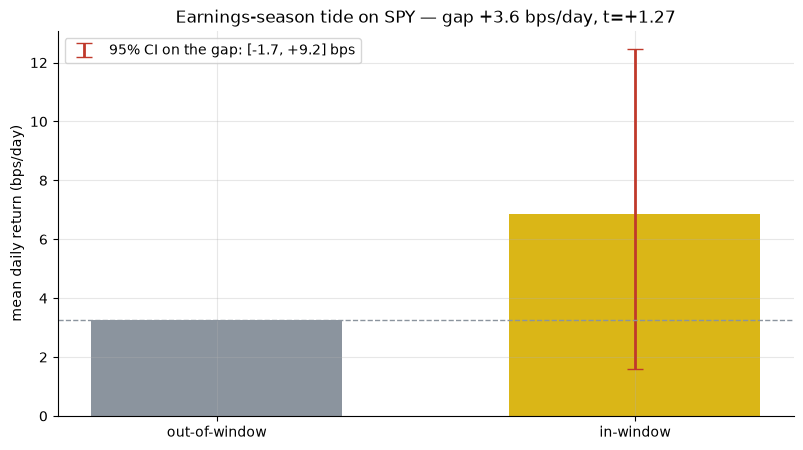

In [3]:
lo, hi = st.block_bootstrap_ci(bars, n_boot=1500, seed=321)
fig, ax = plt.subplots()
ax.bar(['out-of-window','in-window'], [c['mean_out_bps'], c['mean_in_bps']],
       color=[GREY, AMBER], width=.6)
ax.errorbar(['in-window'], [c['mean_in_bps']],
            yerr=[[c['mean_in_bps']-(c['mean_out_bps']+lo)],[(c['mean_out_bps']+hi)-c['mean_in_bps']]],
            fmt='none', ecolor=RED, capsize=6, lw=2,
            label=f'95% CI on the gap: [{lo:+.1f}, {hi:+.1f}] bps')
ax.axhline(c['mean_out_bps'], color=GREY, ls='--', lw=1)
ax.set_ylabel('mean daily return (bps/day)')
ax.set_title(f'Earnings-season tide on {("SPY" if TAPE=="REAL" else "synthetic")}'
             f' — gap {c["diff_bps"]:+.1f} bps/day, t={c["tstat_diff"]:+.2f}')
ax.legend(); plt.show()


And per-quarter — does *any* single earnings window carry a tide? (Cherry-picking the best of four is itself a trap; watch the *t*-stats.)

,window,n_days,mean_bps,tstat
0,Jan (Q4),361,0.367,-0.716
1,Apr (Q1),436,9.150,1.225
2,Jul (Q2),471,5.437,0.325
3,Oct (Q3),469,11.162,1.392


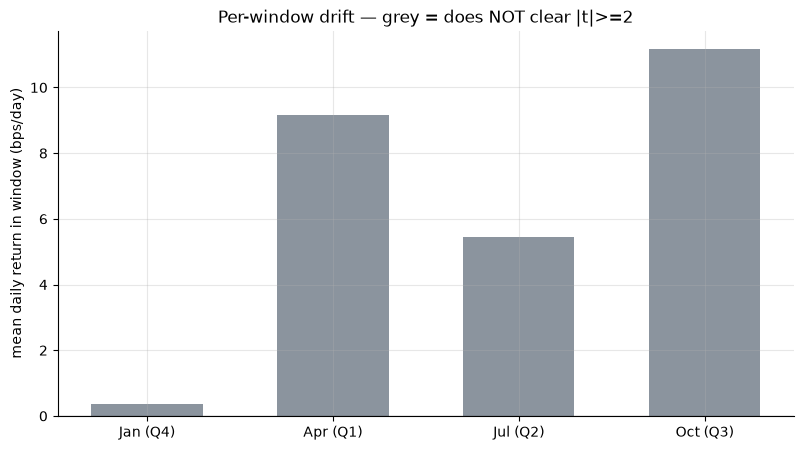

In [4]:
pw = st.per_window_means(bars)
display(pw)
fig, ax = plt.subplots()
cols = [GREEN if abs(t) >= 2 else GREY for t in pw['tstat']]
ax.bar(pw['window'], pw['mean_bps'], color=cols, width=.6)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('mean daily return in window (bps/day)')
ax.set_title('Per-window drift — grey = does NOT clear |t|>=2')
plt.show()
if TAPE != 'REAL':
    print('[banner] SYNTHETIC tape above. On the REAL SPY tape, the strongest '
          f'window is Oct at {R["oct_bps"]:+.1f} bps/day but only t={R["oct_t"]:+.2f}.')


## 5 · The verdict

- **Signal — None.** The in-window days drift a touch faster, but the gap (**+3.6 bps/day** on real SPY) has a robust *t* of only **+1.27** and an error bar **[-1.7, +9.2]** that includes zero. No single quarter clears the bar either.
- **Separable tide? — Not supported.** The real single-stock earnings effect doesn't aggregate into a directional index seasonal; the in-window days are just *some* of the ordinary up-drift days, not a separate tide.

## 6 · Could you actually trade it?

Suppose you ignored the weak statistics and traded it anyway: long the index only inside the windows, cash otherwise. Here's that overlay against simply holding.

In [5]:
race = st.race_vs_buyhold(bars, cost_bps=1.0)
print(f'In-window overlay : {race["overlay_ann_pct"]:+.2f}%/yr   '
      f'Sharpe {race["overlay_sharpe_net"]:.2f}   in market {race["time_in_market"]:.0%}')
print(f'Buy-and-hold      : {race["buyhold_ann_pct"]:+.2f}%/yr   '
      f'Sharpe {race["buyhold_sharpe"]:.2f}   in market 100%')
if TAPE != 'REAL':
    print('\n[banner] SYNTHETIC tape above. Frozen REAL race:')
    print(f'  overlay {R["overlay_ann"]:+.2f}%/yr SR {R["overlay_sr"]:.2f}  vs  '
          f'buy-hold {R["buyhold_ann"]:+.2f}%/yr SR {R["buyhold_sr"]:.2f}')


In-window overlay : +3.54%/yr   Sharpe 0.40   in market 21%
Buy-and-hold      : +10.15%/yr   Sharpe 0.54   in market 100%


On the real tape the overlay earns **~3.5%/yr at Sharpe 0.40** — *worse* than the index's **~10.2%/yr at Sharpe 0.54** — while parking in cash 79% of the year. Even if the tiny gap were real, slicing it out under-performs the thing it's carved from. **Mirage.**

## 7 · Going further 🚪

- **Conditioning on surprise.** A directional tide might only appear in quarters where aggregate surprises skew positive — but that needs forward-looking earnings data and stops being a pure calendar rule.
- **Volatility, not direction.** Maybe earnings season moves *variance* (a vol tide) even if it doesn't move drift — a cleaner question to fork.
- **Window definitions.** We pre-declared the windows; a believer could argue for different week ranges. The honest way to settle that is a data-snooping correction across all plausible windows (Sullivan-Timmermann-White), not hunting for the best one.